# Setup & Data Loading

## Environment Configuration

In [ ]:
import sys
import time
import warnings
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.ndimage import center_of_mass, shift
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, StratifiedKFold, GridSearchCV, train_test_split, learning_curve, cross_val_score
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, pairwise_distances, classification_report, log_loss, confusion_matrix, f1_score
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.datasets import fetch_openml
from tqdm.notebook import tqdm
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.spatial import Voronoi, voronoi_plot_2d
from sklearn.neighbors import NearestCentroid
from sklearn.preprocessing import normalize

# Environment Configuration (Local vs Colab)

if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    base_dir = '/content/drive/MyDrive/MNIST_Project'
else:
    base_dir = '.'

figures_dir = os.path.join(base_dir, 'figures')
os.makedirs(figures_dir, exist_ok=True)

print(f"Setup Completed! Figures will be saved at: {figures_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup Completed! Figures will be saved at: /content/drive/MyDrive/MNIST_Project/figures


## Loading the MNIST Dataset

In [ ]:
print("Fetching MNIST dataset...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

X, y = mnist["data"], mnist["target"].astype(int)

X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Fetching MNIST dataset...
Train: (60000, 784), Test: (10000, 784)


To ensure a meaningful and consistent comparison with our previous results, the dataset was partitioned following the official MNIST protocol, aligning with the 60,000/10,000 training-to-test split used in Project 1 & 2. By manually slicing the dataset and preserving the original sample ordering, we ensured that the test set remains identical to the one used in the TensorFlow/Keras environment, thereby eliminating data variability as a factor in performance differences.

# Data Preprocessing

## Type Casting (float32)

In [ ]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

## Data Normalization

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

Pixel intensities were normalized to the  [0,1]  range by dividing all values by 255.0. This global scaling method is preferred for image data over feature-wise scaling (e.g., MinMaxScaler) because it preserves the relative intensity relationships between pixels and maintains the physical meaning of the image. Furthermore, it avoids computational issues with zero-variance pixels located at the image borders, which are common in the MNIST dataset.

# Feature Engineering

## Spatial Image Centering

Image centering was shown to significantly improve performance in both distance-based, non-linear models (Project 1) and in Linear Models (Project 2). Therefore, this spatial transformation will also be applied in this study. Since, visual verifications of the shifted digits have been shown in our first work (Project 1), they are omitted from this report to maintain focus on the core objectives of this study.

In [ ]:
def center_images(X_data):
    """
    Calculates the center of mass for each image and shifts it so that
    the center of mass aligns with the geometric center (13.5, 13.5).
    Expects normalized data [0, 1].
    """
    N = X_data.shape[0]
    X_centered = np.zeros_like(X_data)

    for i in range(N):
        img = X_data[i].reshape(28, 28)

        # Add 1e-5 to avoid ZeroDivisionError on completely black images
        cy, cx = center_of_mass(img + 1e-5)

        # Calculate shift and apply it
        centered_img = shift(img, shift=(13.5 - cy, 13.5 - cx), mode='constant', cval=0.0)

        X_centered[i] = np.clip(centered_img, 0.0, 1.0).flatten()

    return X_centered

### Apply spatial centering

In [ ]:
X_train = center_images(X_train)
X_test = center_images(X_test)

# Dimensionality Reduction (PCA)

## Custom PCA Implementation

In [ ]:
class CustomPCA:
    def __init__(self, n_components):
       # The number of components to keep
      self.n_components = n_components
      self.mean = None
      self.components = None
      self.explained_variance_ratio = None

    def fit(self, X):
      self.mean = np.mean(X, axis=0)
      X_centered = X - self.mean

      covariance_matrix = (X_centered.T @ X_centered) / (X_centered.shape[0] - 1)

      eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

      indices = np.argsort(eigenvalues)[::-1]
      eigenvalues_sorted = eigenvalues[indices]
      eigenvectors_sorted = eigenvectors[:, indices]

      self.components = eigenvectors_sorted[:, :self.n_components]

      # Calculate the explained variance ratio for the the selected components
      total_variance = np.sum(eigenvalues_sorted)
      self.explained_variance_ratio = eigenvalues_sorted[:self.n_components] / total_variance

    def transform(self, X):
      X_centered = X - self.mean
      X_pca = np.dot(X_centered, self.components)
      return X_pca


Let the dataset be $X$ with dimensions $N \times D$, where $N$ is the number of samples and $D$ is the number of features (784 for the MNIST dataset).

We compute the mean vector of each column (each feature), resulting in a $1 \times D$ vector $\mu$:
$$\mu_j = \frac{1}{N} \sum_{i=1}^{N} X_{i,j}$$

We subtract $\mu$ from the original matrix $X$ to compute the centered data matrix $X_c$:
$$X_c = X - \mu$$

We compute the covariance matrix $\Sigma$, which describes how each pixel changes in relation to the rest, by multiplying the transpose of the centered data matrix by the centered data matrix itself, and dividing by $N-1$. We divide by $N-1$ rather than $N$ to apply Bessel's correction, accounting for the fact that we are analyzing a sample rather than the entire population:
$$\Sigma = \frac{1}{N-1} X_c^T X_c$$

We compute the eigenvalues and eigenvectors of the covariance matrix. Each eigenvalue represents the variance captured along its corresponding direction, and each eigenvector represents a principal component.

We sort the eigenvalues in descending order and sort their corresponding eigenvectors accordingly.

Finally, we keep only the first n_components columns of the sorted eigenvector matrix to form the projection matrix.

## Create subset with 3 classes and 1000 samples each

In [ ]:
target_classes = [0, 1, 8]
samples_per_class = 1000

X_subset = []
y_subset = []

for c in target_classes:
    # Find indices of the current class
    idx = np.where(y_train == c)[0][:samples_per_class]
    X_subset.append(X_train[idx])
    y_subset.append(y_train[idx])

# Combine into flat arrays
X_subset = np.vstack(X_subset)
y_subset = np.hstack(y_subset)

## Cumulative Variance Ratio Across the First 10 Principal Components & Choosing 2 as our number of principal components for the following expiriements

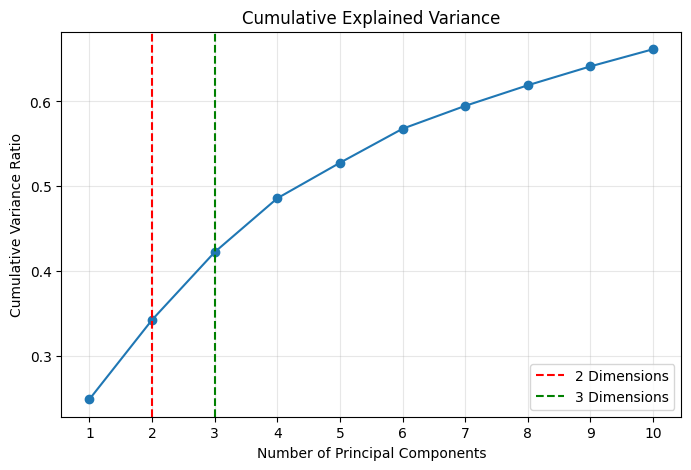

In [ ]:
# Graph: Cumulative Explained Variance Plot
max_dims = 10
pca_variance = CustomPCA(n_components=max_dims)
pca_variance.fit(X_subset)

cumulative_variance = np.cumsum(pca_variance.explained_variance_ratio)

plt.figure(figsize=(8, 5))
plt.plot(range(1, max_dims + 1), cumulative_variance, marker='o', linestyle='-')
plt.axvline(x=2, color='red', linestyle='--', label='2 Dimensions')
plt.axvline(x=3, color='green', linestyle='--', label='3 Dimensions')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Variance Ratio')
plt.xticks(range(1, max_dims + 1))
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f"{figures_dir}/cumulative_explained_variance.pdf", dpi=300, bbox_inches='tight')
plt.show()

## 2D Visualization

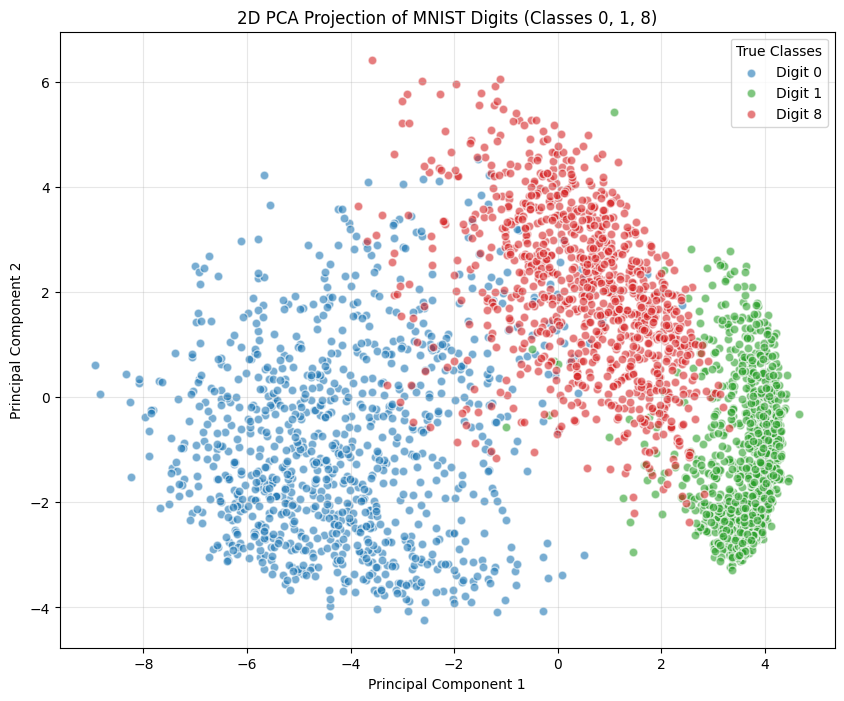

In [ ]:
# Initialize and fit the custom PCA for exactly 2 dimensions
pca_2d = CustomPCA(n_components=2)
pca_2d.fit(X_subset)

# Project the high-dimensional data onto the 2 principal components
X_proj_2d = pca_2d.transform(X_subset)

# Initialize the plot figure
plt.figure(figsize=(10, 8))

# Define the target classes and corresponding explicit colors for clarity
target_classes = [0, 1, 8]
colors = ['tab:blue', 'tab:green', 'tab:red']

# Plot each class separately to map labels to the legend correctly
for i, c in enumerate(target_classes):
    # Extract the indices corresponding to the current class
    idx = np.where(y_subset == c)[0]

    # Scatter plot for the current class
    plt.scatter(X_proj_2d[idx, 0], X_proj_2d[idx, 1],
                c=colors[i], label=f'Digit {c}',
                alpha=0.6, edgecolors='w', s=40)

# Format the plot with titles and grid
plt.title('2D PCA Projection of MNIST Digits (Classes 0, 1, 8)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='True Classes')
plt.grid(True, alpha=0.3)
plt.savefig(f"{figures_dir}/2d_pca_projection.pdf", dpi=300, bbox_inches='tight')
plt.show()

## Pixel Saliency

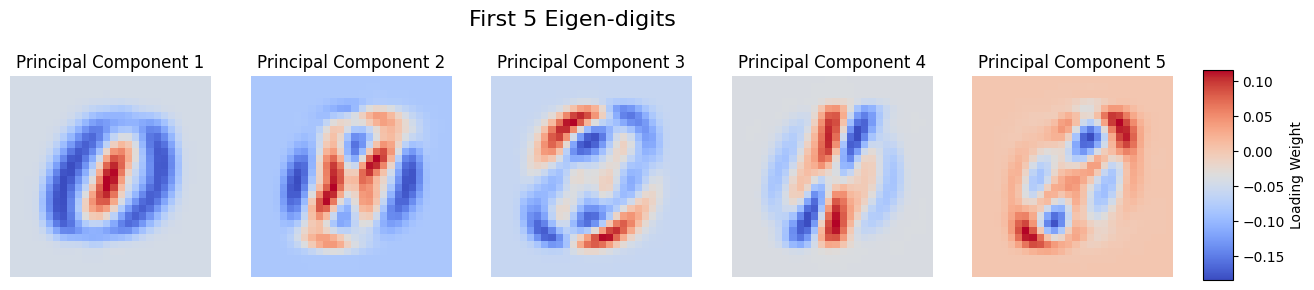

In [ ]:
# Eigen-digits (The "ghosts" of the first 5 Principal Components)
# We need to temporarily fit PCA for 5 dimensions just to extract the first 5 PCs
pca_5d = CustomPCA(n_components=5)
pca_5d.fit(X_subset)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i in range(5):
    # Reshape the eigenvector (column i) back to 28x28
    eigen_digit = pca_5d.components[:, i].reshape(28, 28)

    ax = axes[i]
    # Use a diverging colormap (coolwarm) because weights can be negative or positive
    im = ax.imshow(eigen_digit, cmap='coolwarm')
    ax.set_title(f'Principal Component {i+1}')
    ax.axis('off')

# Add a single colorbar for the figure
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label='Loading Weight')

plt.suptitle('First 5 Eigen-digits', fontsize=16, y=1.05)
plt.savefig(f"{figures_dir}/eigen_digits.pdf", dpi=300, bbox_inches='tight')
plt.show()

## Eigen-digits

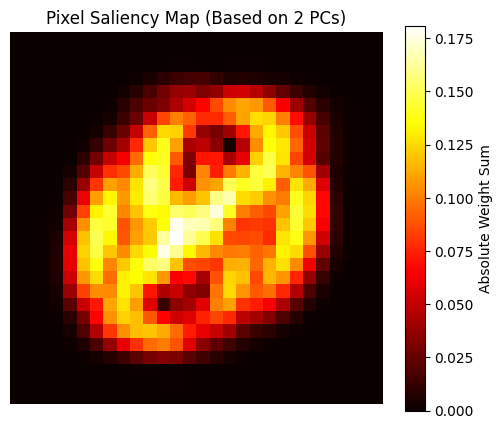

In [ ]:
# Pixel Saliency Map
# Calculate the sum of absolute weights across the first 2 components
# (since we chose 2D projection) to see which pixels matter most.
saliency_map = np.sum(np.abs(pca_2d.components), axis=1).reshape(28, 28)

plt.figure(figsize=(6, 5))
plt.imshow(saliency_map, cmap='hot')
plt.title('Pixel Saliency Map (Based on 2 PCs)')
plt.colorbar(label='Absolute Weight Sum')
plt.axis('off')
plt.savefig(f"{figures_dir}/pixel_saliency_map.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Unsupervised Clustering (k-Means) in Low-Dimensional Space

## Custom k-Means Implementation

In [ ]:
class CustomKMeansPlusPlus:
    def __init__(self, k, max_iter=1000, tol=1e-5):
      self.k = k
      self.cluster_centroids = None
      self.max_iter = max_iter
      self.tol = tol

    def _compute_distances(self, X, centroids):
      # Calculate pairwise Euclidean distances using the algebraic expansion:
      # ||x - c||^2 = ||x||^2 + ||c||^2 - 2*X@C.T
      x_square = np.sum(X**2, axis=1, keepdims=True)
      centroids_square = np.sum(centroids**2, axis=1, keepdims=True).T
      dot_product = np.dot(X, centroids.T)

      distances = x_square + centroids_square - 2 * dot_product

      # Handle possible negative floating point numbers, caused by floating point calculation inaccuracies
      distances = np.maximum(distances, 0)

      return np.sqrt(distances)

    def fit(self, X):
      self.cluster_centroids = np.zeros((self.k, X.shape[1]))
      self.cluster_centroids[0] = X[np.random.choice(X.shape[0])]

      # Initialization (K-Means++)
      for i in range(1, self.k):
        distances = self._compute_distances(X, self.cluster_centroids[:i])
        min_distances = np.min(distances, axis=1)

        probabilities = min_distances**2 / np.sum(min_distances**2)

        self.cluster_centroids[i] = X[np.random.choice(X.shape[0], p=probabilities)]

      # Assign each sample to the nearest centroid
      for _ in range(self.max_iter):
        distances = self._compute_distances(X, self.cluster_centroids)
        labels = np.argmin(distances, axis=1)

        old_centroids = self.cluster_centroids.copy()
        for i in range(self.k):
          cluster_i_samples = X[labels == i]
          if len(cluster_i_samples) > 0:
            self.cluster_centroids[i] = np.mean(cluster_i_samples, axis=0)
          # If a cluster is empty, move its centroid to the sample that is the furthest from each centroid
          else:
            furthest_idx = np.argmax(np.min(distances, axis=1))
            self.cluster_centroids[i] = X[furthest_idx]

        if (np.linalg.norm(self.cluster_centroids - old_centroids) < self.tol):
          break

    def predict(self, X):
      distances = self._compute_distances(X, self.cluster_centroids)
      return np.argmin(distances, axis=1)



## K-Means Clustering on 2D Projections & Performance Evaluation

In [ ]:
# Clustering
np.random.seed(42)
kmeans = CustomKMeansPlusPlus(k=3)
kmeans.fit(X_proj_2d)
cluster_labels = kmeans.predict(X_proj_2d)

# Metrics Calculation
sil_score = silhouette_score(X_proj_2d, cluster_labels)
ari_score = adjusted_rand_score(y_subset, cluster_labels)

df_results = pd.DataFrame({
    "Metric": ["Silhouette Score", "Adjusted Rand Index (ARI)"],
    "Score": [f"{sil_score:.4f}", f"{ari_score:.4f}"]
})

# Confusion Matrix
cm = confusion_matrix(y_subset, cluster_labels)

df_cm = pd.crosstab(
    pd.Series(y_subset, name='True Label'),
    pd.Series(cluster_labels, name='Cluster')
)



# Export to LaTeX
df_results.to_latex(
    os.path.join(figures_dir, 'kmeans_metrics.tex'),
    index=False,
    column_format='lc',
    caption='Performance metrics for K-Means clustering ($K=3$).',
    label='tab:kmeans_metrics'
)

df_cm.to_latex(
    os.path.join(figures_dir, 'kmeans_confusion_matrix.tex'),
    caption='Confusion Matrix: True Labels vs K-Means Assignments.',
    label='tab:cm'
)

print("Metrics Table:")
print(df_results.to_string(index=False))
print("\nConfusion Matrix:")
print(df_cm)

Metrics Table:
                   Metric  Score
         Silhouette Score 0.5279
Adjusted Rand Index (ARI) 0.7004

Confusion Matrix:
Cluster       0    1    2
True Label               
0           855    6  139
1             0  978   22
8            14  158  828


## Comparative Visualization between True Labels and Predicted Clusters with Voronoi Boundaries

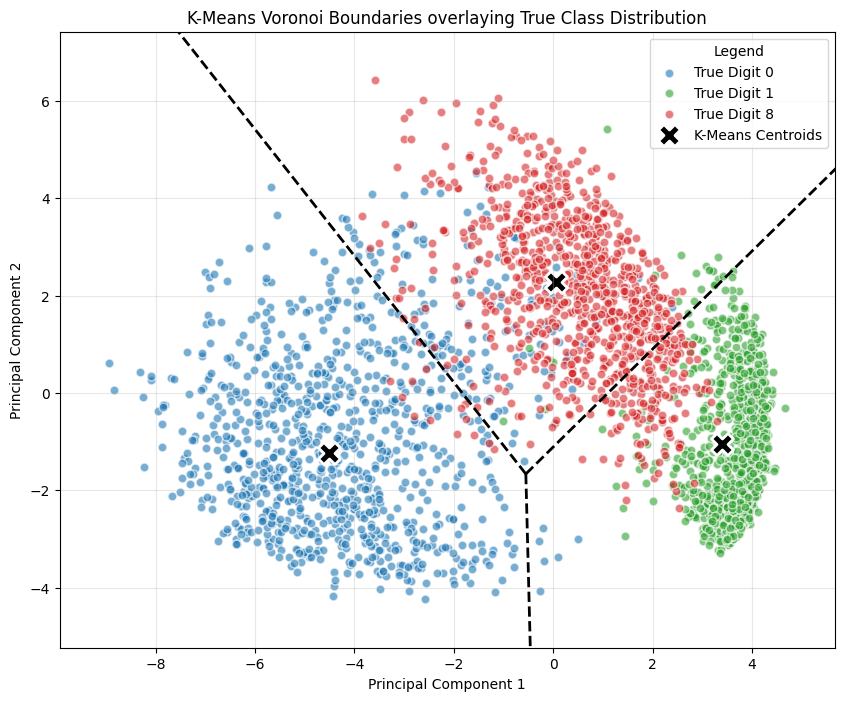

In [ ]:
plt.figure(figsize=(10, 8))

# Calculate and plot Voronoi boundaries based on K-Means centroids
centroids = kmeans.cluster_centroids
vor = Voronoi(centroids)
voronoi_plot_2d(vor, ax=plt.gca(), show_vertices=False, line_colors='k', line_width=2, line_alpha=1.0, point_size=0)

# Plot the data points colored by their true labels
target_classes = [0, 1, 8]
colors_true = ['tab:blue', 'tab:green', 'tab:red']

for i, c in enumerate(target_classes):
    idx = np.where(y_subset == c)[0]
    plt.scatter(X_proj_2d[idx, 0], X_proj_2d[idx, 1],
                c=colors_true[i], label=f'True Digit {c}', alpha=0.6, edgecolors='w', s=40)

# Plot the K-Means centroids
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X', s=250, label='K-Means Centroids', edgecolors='white', linewidths=2)

# Lock the axis limits to prevent the Voronoi function from zooming in and cropping data
plt.xlim([X_proj_2d[:, 0].min() - 1, X_proj_2d[:, 0].max() + 1])
plt.ylim([X_proj_2d[:, 1].min() - 1, X_proj_2d[:, 1].max() + 1])

plt.title('K-Means Voronoi Boundaries overlaying True Class Distribution')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Legend')
plt.grid(True, alpha=0.3)
plt.savefig(f"{figures_dir}/true_labels_and_voronoi_boundaries.pdf", dpi=300, bbox_inches='tight')
plt.show()

## Centroid Reconstruction in Original High-Dimensional Space

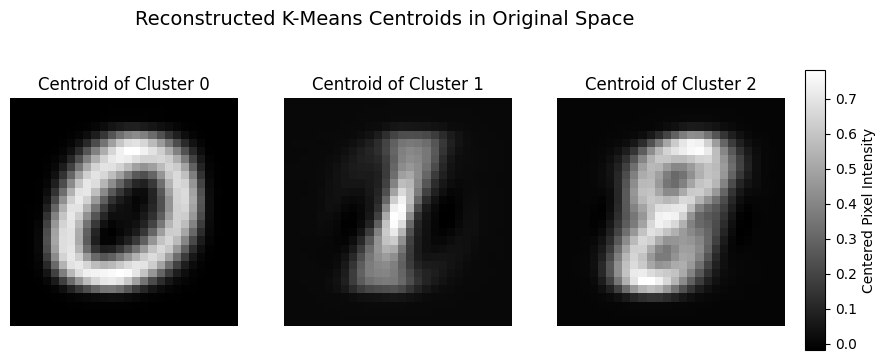

In [ ]:
# Compute the inverse projection: (3, 2) @ (2, 784) = (3, 784)
# and add the mean vector to restore centroids to their original pixel scale.
reconstructed_centroids = np.dot(kmeans.cluster_centroids, pca_2d.components.T) + pca_2d.mean

fig, axes = plt.subplots(1, 3, figsize=(10, 4))

for i in range(3):
    # Reshape the flat 784-dimensional vector back into a 28x28 image grid
    centroid_image = reconstructed_centroids[i].reshape(28, 28)

    ax = axes[i]
    # Use a diverging colormap to accurately represent positive and negative pixel intensities (centered data)
    im = ax.imshow(centroid_image, cmap='gray')
    ax.set_title(f'Centroid of Cluster {i}')
    ax.axis('off')

# Add a shared colorbar to indicate the scale of the centered pixel values
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label='Centered Pixel Intensity')

plt.suptitle('Reconstructed K-Means Centroids in Original Space', fontsize=14, y=1.00)
plt.savefig(f"{figures_dir}/reconstructed_centroids.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Mahalanobis Classification & Subclasses Approach

## PCA as a Prerequisite for Mahalanobis Distance

In [ ]:
pca_10d = CustomPCA(n_components=10)
pca_10d.fit(X_train)
X_train_10d = pca_10d.transform(X_train)
X_test_10d = pca_10d.transform(X_test)

print("Shape of X_train_10d:", X_train_10d.shape)
print("Shape of X_test_10d:", X_test_10d.shape)

Shape of X_train_10d: (60000, 10)
Shape of X_test_10d: (10000, 10)


## Baseline Nearest Centroid Classifier

In [ ]:
clf_ncc = NearestCentroid()
clf_ncc.fit(X_train_10d, y_train)
y_pred_ncc = clf_ncc.predict(X_test_10d)

acc_ncc = accuracy_score(y_test, y_pred_ncc)
print(f"Accuracy of Nearest Centroid Classifier on 10D PCA data: {acc_ncc:.4f}")

Accuracy of Nearest Centroid Classifier on 10D PCA data: 0.7614


## Custom Mahalanobis-based Nearest Centroid Classifier Implementation

In [ ]:
class CustomMahalanobisNCC:
  def __init__(self):
    self.class_mean = {}
    self.class_inv_cov = {}
    self.subclass_mapping = None

  def fit(self, X, y, subclass_mapping=None):
    self.subclass_mapping = subclass_mapping
    classes = np.unique(y)
    for c in classes:
      class_indices = np.where(y == c)[0]
      class_data = X[class_indices]

      self.class_mean[c] = np.mean(class_data, axis=0)

      class_cov = np.cov(class_data, rowvar=False)
      class_cov += 1e-5 * np.eye(class_cov.shape[0])
      self.class_inv_cov[c] = np.linalg.inv(class_cov)

  def predict(self, X):
    classes = list(self.class_mean.keys())
    distances_sq = np.zeros((X.shape[0], len(classes)))

    for i, c in enumerate(classes):
      mean_diff = X - self.class_mean[c]
      distances_sq[:, i] = np.sum(np.dot(mean_diff, self.class_inv_cov[c]) * mean_diff, axis=1)

    min_indices = np.argmin(distances_sq, axis=1)
    predictions = np.array([classes[i] for i in min_indices])

    if self.subclass_mapping is not None:
      predictions = np.array([self.subclass_mapping[pred] for pred in predictions])

    return predictions


## Mahalanobis-based Classification (10 Classes)

Accuracy with 10 classes (Mahalanobis): 0.8929


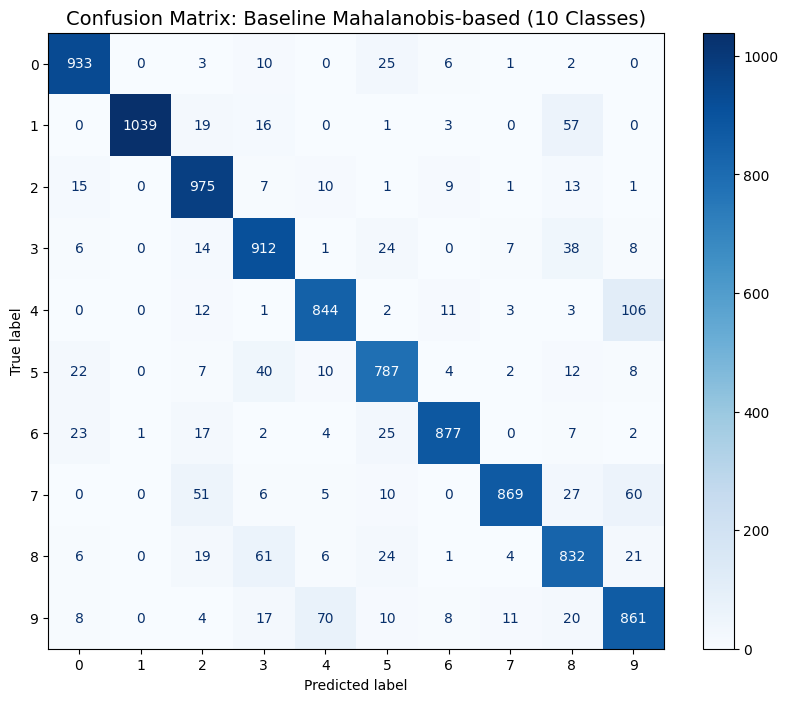

In [ ]:
clf_10 = CustomMahalanobisNCC()
clf_10.fit(X_train_10d, y_train)
y_pred_10 = clf_10.predict(X_test_10d)

acc_10 = accuracy_score(y_test, y_pred_10)

print(f"Accuracy with 10 classes (Mahalanobis): {acc_10:.4f}")

# Confusion Matrix Display
labels_10 = np.arange(10)
cm_10 = confusion_matrix(y_test, y_pred_10, labels=labels_10)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_10, display_labels=labels_10)
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix: Baseline Mahalanobis-based (10 Classes)', fontsize=14)
plot_path_cm_10 = os.path.join(figures_dir, 'mahalanobis_10_cm.pdf')
plt.savefig(plot_path_cm_10, dpi=300, bbox_inches='tight')
plt.show()

## A More Sophisticated Classification with 20 Class (2 Clusters per Class) & Performance Evaluation

Accuracy with 20 subclasses (Mahalanobis): 0.9022


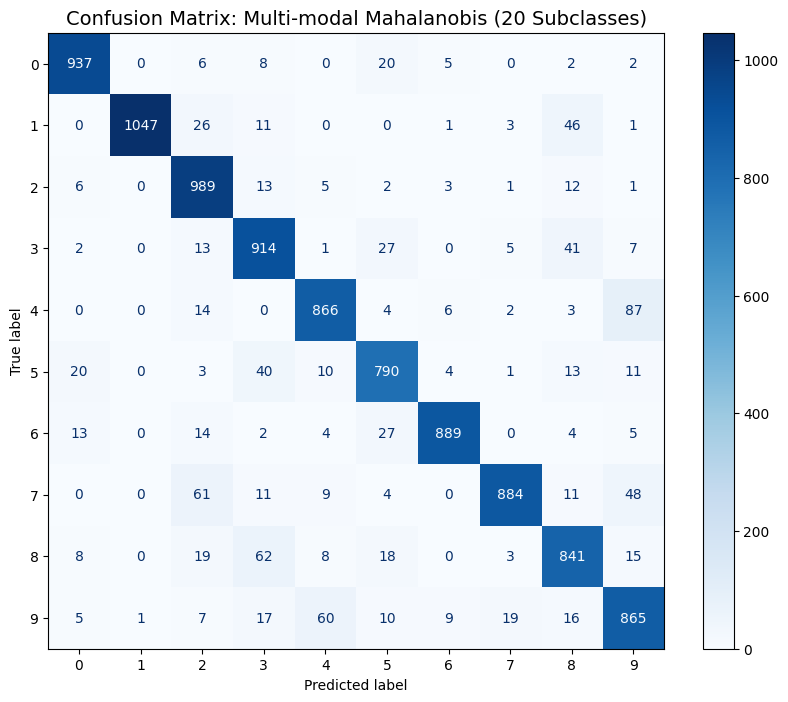

In [ ]:
# Create 2 Subclasses for each Class
y_train_subclasses = np.empty_like(y_train, dtype=object)
subclass_to_true_label = {}

for digit in range(10):
    # Isolate data for the specific digit
    idx = (y_train == digit)
    X_digit = X_train_10d[idx]

    # Apply K-Means to split the digit into 2 subclasses
    kmeans = CustomKMeansPlusPlus(k=2)
    kmeans.fit(X_digit)
    sub_labels = kmeans.predict(X_digit)

    # Create unique subclass IDs (e.g., '0_0' and '0_1')
    unique_sub_labels = np.array([f"{digit}_{sub_id}" for sub_id in sub_labels])
    y_train_subclasses[idx] = unique_sub_labels

    # Store the mapping back to the original digit
    subclass_to_true_label[f"{digit}_0"] = digit
    subclass_to_true_label[f"{digit}_1"] = digit

# Classification with 20 Subclasses
clf_20 = CustomMahalanobisNCC()
clf_20.fit(X_train_10d, y_train_subclasses, subclass_mapping=subclass_to_true_label)
y_pred_20 = clf_20.predict(X_test_10d)
acc_20 = accuracy_score(y_test, y_pred_20)

print(f"Accuracy with 20 subclasses (Mahalanobis): {acc_20:.4f}")

# Confusion Matrix Display
labels_20 = np.arange(10)
cm_20 = confusion_matrix(y_test, y_pred_20, labels=labels_20)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_20, display_labels=labels_20)
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix: Multi-modal Mahalanobis (20 Subclasses)', fontsize=14)
plot_path_cm_20 = os.path.join(figures_dir, 'mahalanobis_20_cm.pdf')
plt.savefig(plot_path_cm_20, dpi=300, bbox_inches='tight')
plt.show()


# Further Experiment: Spherical PCA and Cosine Equivalence

In [ ]:
# Apply L2 normalization to the original 784D data
X_train_l2 = normalize(X_train, norm='l2', axis=1)
X_test_l2 = normalize(X_test, norm='l2', axis=1)

# Perform Spherical PCA (10d)
pca_spherical = CustomPCA(n_components=10)
X_train_spherical = pca_spherical.fit(X_train_l2)
X_train_spherical = pca_spherical.transform(X_train_l2)
X_test_spherical = pca_spherical.transform(X_test_l2)

# Baseline NCC + Spherical PCA
clf_base_spherical = NearestCentroid()
clf_base_spherical.fit(X_train_spherical, y_train)
y_pred_base_spherical = clf_base_spherical.predict(X_test_spherical)
acc_base_spherical = accuracy_score(y_test, y_pred_base_spherical)

print(f"Baseline NCC: {acc_ncc:.4f}")
print(f"Baseline NCC + Spherical PCA: {acc_base_spherical:.4f}")

Baseline NCC: 0.7614
Baseline NCC + Spherical PCA: 0.7661


# Ablation Study Results

In [ ]:
# Evaluate the remaining approach combinations

# Baseline NCC + 2 Subclasses
clf_base_subclasses = NearestCentroid()
clf_base_subclasses.fit(X_train_10d, y_train_subclasses)
y_pred_base_subclasses_raw = clf_base_subclasses.predict(X_test_10d)
y_pred_base_subclasses = np.array([subclass_to_true_label[p] for p in y_pred_base_subclasses_raw])
acc_base_subclasses = accuracy_score(y_test, y_pred_base_subclasses)

# Baseline NCC + 2 Subclasses + Spherical PCA
clf_base_subclasses_spherical = NearestCentroid()
clf_base_subclasses_spherical.fit(X_train_spherical, y_train_subclasses)
y_pred_base_subclasses_spherical_raw = clf_base_subclasses_spherical.predict(X_test_spherical)
y_pred_base_subclasses_spherical = np.array([subclass_to_true_label[p] for p in y_pred_base_subclasses_spherical_raw])
acc_base_subclasses_spherical = accuracy_score(y_test, y_pred_base_subclasses_spherical)

# Mahalanobis NCC + Spherical PCA
clf_mah_spherical = CustomMahalanobisNCC()
clf_mah_spherical.fit(X_train_spherical, y_train)
y_pred_mah_spherical = clf_mah_spherical.predict(X_test_spherical)
acc_mah_spherical = accuracy_score(y_test, y_pred_mah_spherical)

# Mahalanobis NCC + 2 Subclasses + Spherical PCA
clf_mah_subclasses_spherical = CustomMahalanobisNCC()
clf_mah_subclasses_spherical.fit(X_train_spherical, y_train_subclasses, subclass_mapping=subclass_to_true_label)
y_pred_mah_subclasses_spherical = clf_mah_subclasses_spherical.predict(X_test_spherical)
acc_mah_subclasses_spherical = accuracy_score(y_test, y_pred_mah_subclasses_spherical)

# Create the data structure for the Ablation Study table
ablation_data = [
    {"Distance Metric (Classifier)": "Euclidean", "Subclasses per Digit": 1, "Feature Space (PCA Type)": "Standard", "Accuracy": acc_ncc},
    {"Distance Metric (Classifier)": "Euclidean", "Subclasses per Digit": 1, "Feature Space (PCA Type)": "Spherical (L2)", "Accuracy": acc_base_spherical},
    {"Distance Metric (Classifier)": "Euclidean", "Subclasses per Digit": 2, "Feature Space (PCA Type)": "Standard", "Accuracy": acc_base_subclasses},
    {"Distance Metric (Classifier)": "Euclidean", "Subclasses per Digit": 2, "Feature Space (PCA Type)": "Spherical (L2)", "Accuracy": acc_base_subclasses_spherical},
    {"Distance Metric (Classifier)": "Mahalanobis", "Subclasses per Digit": 1, "Feature Space (PCA Type)": "Standard", "Accuracy": acc_10},
    {"Distance Metric (Classifier)": "Mahalanobis", "Subclasses per Digit": 1, "Feature Space (PCA Type)": "Spherical (L2)", "Accuracy": acc_mah_spherical},
    {"Distance Metric (Classifier)": "Mahalanobis", "Subclasses per Digit": 2, "Feature Space (PCA Type)": "Standard", "Accuracy": acc_20},
    {"Distance Metric (Classifier)": "Mahalanobis", "Subclasses per Digit": 2, "Feature Space (PCA Type)": "Spherical (L2)", "Accuracy": acc_mah_subclasses_spherical}
]

df_ablation = pd.DataFrame(ablation_data)
df_ablation["Accuracy"] = df_ablation["Accuracy"].apply(lambda x: f"{x:.4f}")
print(df_ablation.to_string(index=False))

latex_path_ablation = os.path.join(figures_dir, 'ablation_study_results.tex')
df_ablation.to_latex(
    latex_path_ablation,
    index=False,
    caption='Ablation study demonstrating the independent and combined effects of distance metrics, multimodal clustering (subclasses), and geometric transformations (Spherical PCA) on classification accuracy.',
    label='tab:ablation_study'
)

Distance Metric (Classifier)  Subclasses per Digit Feature Space (PCA Type) Accuracy
                   Euclidean                     1                 Standard   0.7614
                   Euclidean                     1           Spherical (L2)   0.7661
                   Euclidean                     2                 Standard   0.8095
                   Euclidean                     2           Spherical (L2)   0.8199
                 Mahalanobis                     1                 Standard   0.8929
                 Mahalanobis                     1           Spherical (L2)   0.9033
                 Mahalanobis                     2                 Standard   0.9022
                 Mahalanobis                     2           Spherical (L2)   0.9132
